In [1]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from sklearn.linear_model import LinearRegression
import importlib

from pcntoolkit.dataio.norm_data import NormData
from pcntoolkit.normative_model import NormativeModel
from pcntoolkit.regression_model.blr import BLR
from pcntoolkit.util.plotter import plot_centiles, plot_centiles_advanced
import pcntoolkit.math_functions.thrive as thrive
importlib.reload(thrive)

<module 'pcntoolkit.math_functions.thrive' from '/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/pcntoolkit/math_functions/thrive.py'>

Process: 97309 - 2026-03-04 15:09:32 - Dataset "dummy" created.
    - 5000 observations
    - 500 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	groups (5)
    


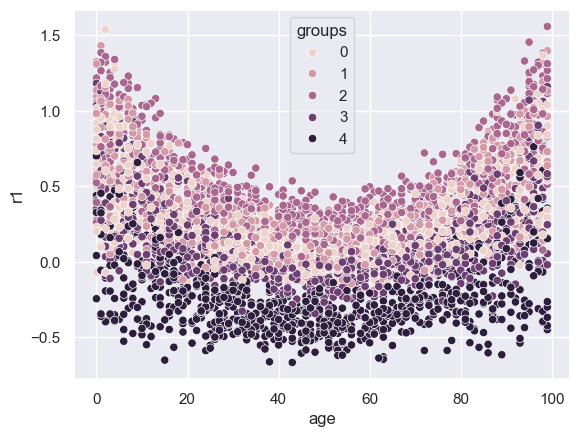

In [2]:
n_subjects = 500
n_samples = 5000
max_age = 100
np.random.seed(20)
subjects = np.random.choice(n_subjects, n_samples, replace=True)
coefs = np.random.rand(n_subjects, 2)
n_groups = 5
groups = np.random.choice(n_groups, n_subjects, replace=True)
groups = groups[subjects]
group_offsets = np.random.randn(n_groups) * 0.003
covariates = np.random.choice(max_age, n_samples).astype(float)
responses1 = (
    0.05 * (covariates / max_age - 1 / 2) ** 2 * coefs[subjects, 0] + np.random.randn(n_samples) * 0.001 + group_offsets[groups]
)
responses2 = (
    0.05 * (covariates / max_age - 1 / 2) ** 3 * coefs[subjects, 1] + np.random.randn(n_samples) * 0.001 + group_offsets[groups]
)
responses = np.stack((responses1, responses2), axis=1) * 100
df = pd.DataFrame({"age": covariates, "r1": responses[:, 0], "r2": responses[:, 1], "subjects": subjects, "groups": groups})
sns.scatterplot(df, x="age", y="r1", hue="groups")

data = NormData.from_dataframe(
    name="dummy", dataframe=df, covariates=["age"], batch_effects=["groups"], response_vars=["r1", "r2"], subject_ids="subjects"
)
train, test = data.train_test_split(splits=0.9)


In [3]:
print(train)

<xarray.NormData> Size: 558kB
Dimensions:            (observations: 4500, response_vars: 2, covariates: 1,
                        batch_effect_dims: 1)
Coordinates:
  * observations       (observations) int64 36kB 2240 3704 1502 ... 4191 2861
  * response_vars      (response_vars) <U2 16B 'r1' 'r2'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U6 24B 'groups'
Data variables:
    subject_ids        (observations) int64 36kB 160 134 182 25 ... 341 445 424
    Y                  (observations, response_vars) float64 72kB 0.01143 ......
    X                  (observations, covariates) float64 36kB 3.0 43.0 ... 12.0
    batch_effects      (observations, batch_effect_dims) <U21 378kB '3' ... '3'
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           dummy_train
    unique_batch_effects:           {np.str_('groups'): [np.str_('0'), np.str...
    batch_effect_counts:   

In [4]:
from pcntoolkit import BsplineBasisFunction

regmodel = BLR(
    heteroskedastic=False,
    fixed_effect=True,
    basis_function_mean=BsplineBasisFunction(0, 3, 5),
    basis_function_var=BsplineBasisFunction(0, 3, 5),
)
model = NormativeModel(template_regression_model=regmodel, inscaler="none", outscaler="none")
model.fit(train)

Process: 97309 - 2026-03-04 15:09:37 - Fitting models on 2 response variables.
Process: 97309 - 2026-03-04 15:09:37 - Fitting model for r1.
Process: 97309 - 2026-03-04 15:09:37 - Fitting model for r2.
Process: 97309 - 2026-03-04 15:09:37 - Making predictions on 2 response variables.
Process: 97309 - 2026-03-04 15:09:37 - Computing z-scores for 2 response variables.
Process: 97309 - 2026-03-04 15:09:37 - Computing z-scores for r2.
Process: 97309 - 2026-03-04 15:09:37 - Computing z-scores for r1.
Process: 97309 - 2026-03-04 15:09:37 - Computing centiles for 2 response variables.
Process: 97309 - 2026-03-04 15:09:37 - Computing centiles for r2.
Process: 97309 - 2026-03-04 15:09:37 - Computing centiles for r1.
Process: 97309 - 2026-03-04 15:09:37 - Computing log-probabilities for 2 response variables.
Process: 97309 - 2026-03-04 15:09:37 - Computing log-probabilities for r2.
Process: 97309 - 2026-03-04 15:09:37 - Computing log-probabilities for r1.
Process: 97309 - 2026-03-04 15:09:37 - Co

Process: 97309 - 2026-03-04 15:09:40 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	groups (1)
    
Process: 97309 - 2026-03-04 15:09:40 - Computing centiles for 2 response variables.
Process: 97309 - 2026-03-04 15:09:40 - Computing centiles for r2.
Process: 97309 - 2026-03-04 15:09:40 - Computing centiles for r1.
Process: 97309 - 2026-03-04 15:09:40 - Harmonizing data on 2 response variables.
Process: 97309 - 2026-03-04 15:09:40 - Harmonizing data for r2.
Process: 97309 - 2026-03-04 15:09:40 - Harmonizing data for r1.


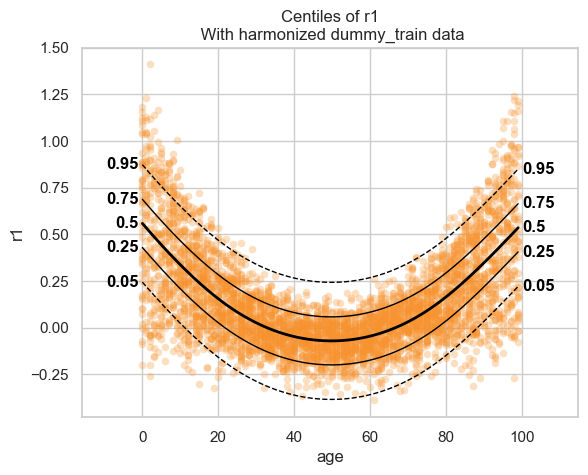

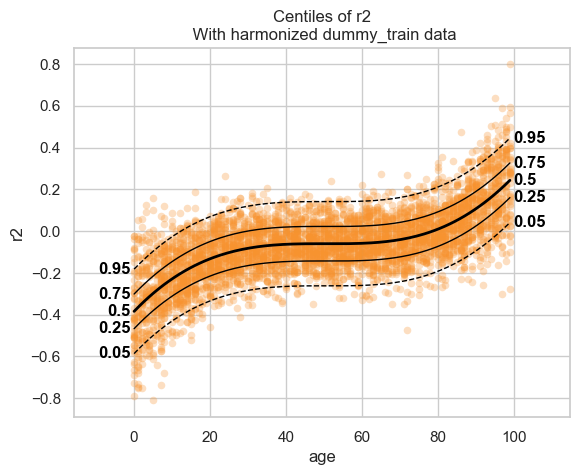

In [5]:
plot_centiles(model, scatter_data=train, covariate="age")

In [ ]:
#model.compute_thrivelines(train, z_thrive=1.5)

AttributeError: 'NoneType' object has no attribute 'sel'

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/pcntoolkit/math_functions/thrive.py:100: RuntimeWarning: divide by zero encountered in divide
  return 0.5 * np.log((1 + cor) / (1 - cor))


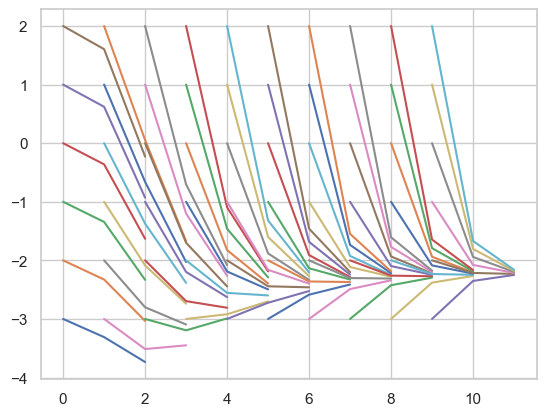

In [25]:
ages, trajectories = thrive.compute_thrivelines(data=train, bandwidth=2, age_range=(0, 10, 1),
                        trajectory_length=3, centile_params=(-3, 3, -1.96))
plt.plot(ages, trajectories)
plt.show()

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/pcntoolkit/math_functions/thrive.py:100: RuntimeWarning: divide by zero encountered in divide
  return 0.5 * np.log((1 + cor) / (1 - cor))


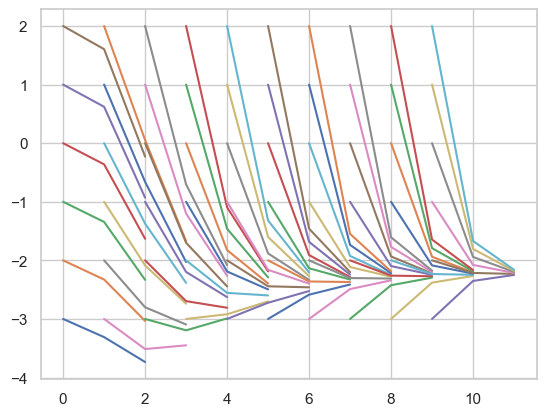

In [7]:
thrive.plot_thrivelines(train)    

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/pcntoolkit/math_functions/thrive.py:100: RuntimeWarning: divide by zero encountered in divide
  return 0.5 * np.log((1 + cor) / (1 - cor))


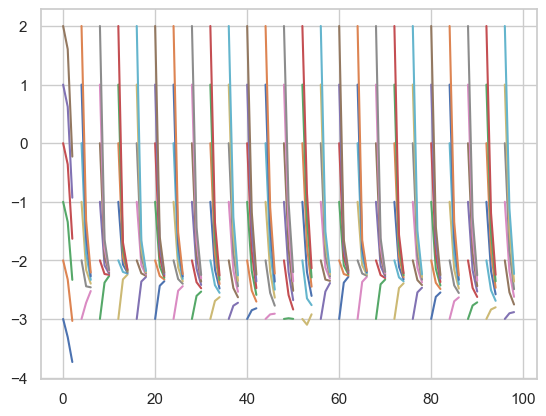

In [30]:
bandwidth = 2
cors, newcors = thrive.get_correlation_matrix(train, bandwidth)
diagonal = np.diagonal(newcors.to_numpy(), offset=-1)
length_of_thrivelines = 3
thrive_Z, ages = thrive.get_thrivelines(diagonal, 0, 100, 4, length_of_thrivelines, -3, 3, -1.96)
shaped_lines = thrive_Z.reshape((-1, length_of_thrivelines))
shaped_ages = ages.reshape((-1, length_of_thrivelines))
plt.plot(shaped_ages.T, shaped_lines.T)
plt.show()

In [31]:
# ── Pipe shaped_lines / shaped_ages through backward() → xdata ───────────────

# 1. Reference batch effect (integer dtype required for one-hot indexing)
n_obs = shaped_lines.shape[0]   # 60 trajectories
be_dims = list(model.unique_batch_effects.keys())
ref_be_integers = np.array(
    [[model.batch_effects_maps[k][model.unique_batch_effects[k][0]]] * n_obs
     for k in be_dims],
    dtype=int,
).T   # (60, n_be_dims)
ref_be = xr.DataArray(
    ref_be_integers,
    dims=("observations", "batch_effect_dims"),
    coords={"batch_effect_dims": be_dims},
)

# 2. For each response variable, back-transform Z → Y at every offset step
offsets = np.arange(shaped_lines.shape[1])   # [0, 1, 2, 3, 4, 5]
thrive_Y_dict = {}
for rv in model.response_vars:
    thrive_Y = np.zeros_like(shaped_lines)
    for io in offsets:
        X_at_offset = xr.DataArray(
            shaped_ages[:, io:io+1],   # (60, 1)
            dims=("observations", "covariates"),
            coords={"covariates": ["age"]},
        )
        Z_at_offset = xr.DataArray(shaped_lines[:, io], dims=("observations",))
        thrive_Y[:, io] = model[rv].backward(X_at_offset, ref_be, Z_at_offset).values
    thrive_Y_dict[rv] = thrive_Y

# 3. Pack into xdata
coords = {
    "trajectory": np.arange(n_obs),
    "offset": offsets,
    "response_vars": model.response_vars,
}
xdata = xr.Dataset({
    "thrive_Z": xr.DataArray(
        np.stack([shaped_lines for _ in model.response_vars], axis=0),
        dims=("response_vars", "trajectory", "offset"),
        coords=coords,
    ),
    "thrive_Y": xr.DataArray(
        np.stack([thrive_Y_dict[rv] for rv in model.response_vars], axis=0),
        dims=("response_vars", "trajectory", "offset"),
        coords=coords,
    ),
    "thrive_X": xr.DataArray(
        shaped_ages,
        dims=("trajectory", "offset"),
        coords={k: coords[k] for k in ("trajectory", "offset")},
    ),
})
print(xdata)

<xarray.Dataset> Size: 19kB
Dimensions:        (trajectory: 150, offset: 3, response_vars: 2)
Coordinates:
  * trajectory     (trajectory) int64 1kB 0 1 2 3 4 5 ... 145 146 147 148 149
  * offset         (offset) int64 24B 0 1 2
  * response_vars  (response_vars) <U2 16B 'r1' 'r2'
Data variables:
    thrive_Z       (response_vars, trajectory, offset) float64 7kB -3.0 ... -...
    thrive_Y       (response_vars, trajectory, offset) float64 7kB 0.1141 ......
    thrive_X       (trajectory, offset) float64 4kB 0.0 1.0 2.0 ... 97.0 98.0


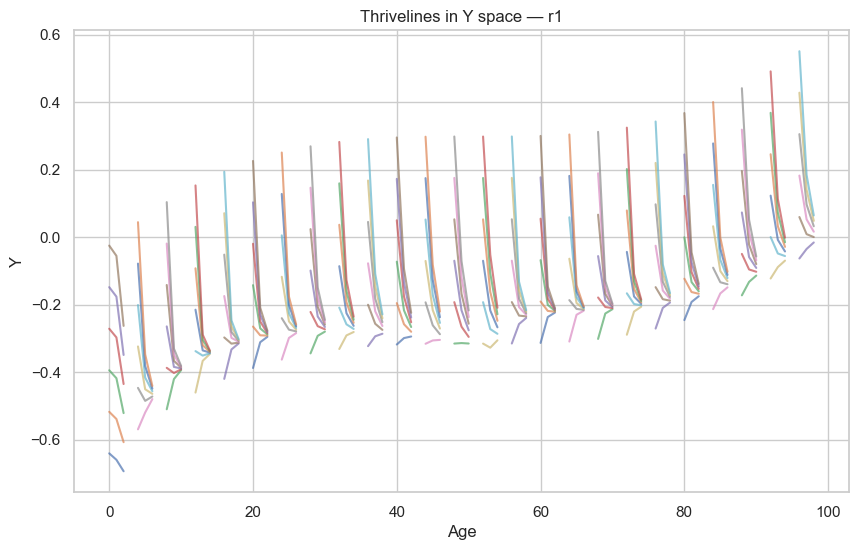

In [32]:
Y = xdata["thrive_Y"].sel(response_vars="r2")   # (trajectory, offset)
X = xdata["thrive_X"]                            # (trajectory, offset)

plt.figure(figsize=(10, 6))
plt.plot(X.values.T, Y.values.T, alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Y")
plt.title("Thrivelines in Y space — r1")
plt.show()

In [ ]:
# This is the code part I need help with. I want to make predictions for the data generated in the parts above, but in this section.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pcntoolkit.dataio.norm_data import NormData
from pcntoolkit.normative_model import NormativeModel
from pcntoolkit.regression_model.blr import BLR
from pcntoolkit.util.output import Output, Warnings

Output
Warnings



def get_thrive_Z_X(cors: xr.DataArray, start_x: xr.DataArray, start_z: xr.DataArray, span: int, z_thrive=-1.96):
    assert start_x.shape == start_z.shape
    assert cors.shape[0] == cors.shape[1]
    padded_cors = np.pad(cors, ((0, span), (0, span)), mode="edge")
    thrive_Z = np.zeros((start_x.shape[0], span + 1))
    thrive_X = np.zeros_like(thrive_Z).astype(int)
    thrive_X[:, 0] = start_x
    thrive_Z[:, 0] = start_z
    for i in range(span):
        thrive_X[:, i + 1] = thrive_X[:, i] + 1
        this_cors = padded_cors[thrive_X[:, i], thrive_X[:, i + 1]]
        thrive_Z[:, i + 1] = thrive_Z[:, i] * this_cors + np.sqrt(1 - this_cors**2) * z_thrive
    thrive_Z = xr.DataArray(thrive_Z, dims=("observations", "offset"))
    thrive_X = xr.DataArray(thrive_X, dims=("observations", "offset"))
    return thrive_Z, thrive_X


def compute_thrivelines(
    self: NormativeModel, data: NormData, span: int = 5, step: int = 1, covariate="age", **kwargs
) -> NormData:
    """
    Computes the thrivelines for each responsevar in the data
    """
    # TODO: Compute correlation matrix during fit
    # TODO: Write utility function to create a normdata object for easy thriveline creation (with appropriate Z scores)
    offsets = np.arange(0, span + 1, step=step)
    # Compute the thrivelines
    # Add them to the dataset, label them correctly

    # Drop the thrivelines and dimensions if they already exist
    centiles_already_computed = "thrive_Z" in data or "thrive_Y" in data or "offset" in data.coords
    if centiles_already_computed:
        if not kwargs.get("recompute", False):
            if all([c in data.offset.values for c in offsets]):
                Output.warning(Warnings.THRIVELINES_ALREADY_COMPUTED_FOR, dataset_name=data.attrs["name"], offsets=offsets)
                return data
        data = data.drop_vars(["thrive_Z"])
        data = data.drop_vars(["thrive_Y"])
        data = data.drop_dims(["offset"])

    # Make Z-score predictions if needed
    if not hasattr(data, "Z"):
        self.predict(data)

    respvar_intersection = list(set(self.response_vars).intersection(data.response_vars.values))
  
    # Get the covariate matrix that was derived during fit
    cormat = get_correlation_matrix(data, 3, covariate)

    # Create X, Y, and Z for thrivelines data
    data["thrive_Z"] = xr.DataArray(
        np.zeros((data.X.shape[0], len(respvar_intersection), offsets.shape[0])),
        dims=("observations", "response_vars", "offset"),
        coords={"offset": offsets},
    )
    data["thrive_Y"] = xr.DataArray(
        np.zeros((data.X.shape[0], len(respvar_intersection), offsets.shape[0])),
        dims=("observations", "response_vars", "offset"),
        coords={"offset": offsets},
    )
    data["thrive_X"] = xr.DataArray(
        np.zeros((data.X.shape[0], offsets.shape[0])),
        dims=("observations", "offset"),
        coords={"offset": offsets},
    )
    for responsevar in respvar_intersection:
        resp_predict_data = data.sel({"response_vars": responsevar})
        X, be, be_maps, m, Z = self.extract_data(resp_predict_data)
        X_cov = X.sel({"covariates": covariate})
        thrive_Z, thrive_X = get_thrive_Z_X(cormat.sel({"response_vars": responsevar}), X_cov, Z, span)
        data["thrive_X"] = xr.DataArray(
            thrive_X,
            dims=("observations", "offset"),
            coords={"offset": offsets},
        )
        data["thrive_Z"].loc[{"response_vars": responsevar}] = thrive_Z
        for io, o in enumerate(offsets):
            this_Z = thrive_Z[:, io]
            data["thrive_Y"].loc[{"response_vars": responsevar, "offset": o}] = self[responsevar].backward(X, be, this_Z)
    self.postprocess(data)
    return data


data = compute_thrivelines(model, data, recompute=True)

NameError: name 'offset_indices' is not defined

 ...]

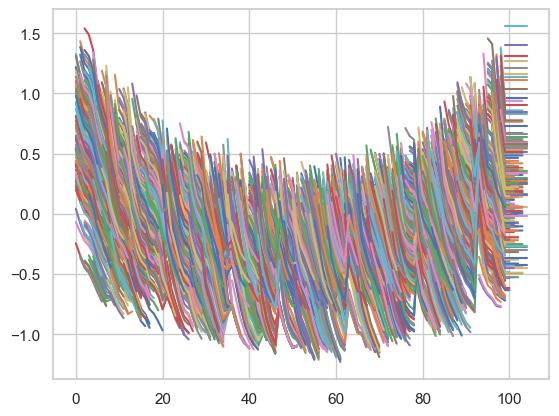

In [ ]:
X_thrive = data["thrive_X"]
Y_thrive = data["thrive_Y"].sel({"response_vars": "r1"})
Z_thrive = data["thrive_Z"].sel({"response_vars": "r1"})
plt.plot(X_thrive.T, Y_thrive.T)